<center>
    <img src="https://weclouddata.s3.amazonaws.com/images/logos/wcd_logo_new_2.png" width='30%'>
</center>

----------

# <p style="font-size:30px;text-align:center"><b>Lab - Pandas Data Processing</b></p>
<br>
<center align="left"> <font size='4'>  Developed by: </font><font size='4' color='#33AAFB'>WeCloudData</font></center>
<br>

----------

## Overview

In this lab, you will practice the pandas skills covered so far on a single realistic dataset: customer records from a telecom company, including the services each customer subscribes to and whether they churned (left the company). The lab is a set of 13 numbered questions. Most questions state what to produce and leave the how to you, and several show more than one valid method side by side. By the end, you will have cleaned the dataset, built new categorical columns, filtered and ranked customers, and explored the churned customers in depth.

## Learning Objectives

By the end of this lab, you will be able to:

- Load a CSV dataset and inspect its size, data types, and missing values.
- Replace values in columns using `replace` and `map`.
- Convert a column's data type and handle non-numeric placeholder values.
- Sort, rank, and select top-N records.
- Build new categorical columns with list comprehensions and `apply`.
- Filter rows using boolean masks, including compound AND/OR conditions.
- Combine DataFrames with `pd.concat` and reorder labels with `reindex`.
- Use index alignment to compare two Series.

### Prerequisites

- The pandas slide decks covered so far: pandas objects, reading and writing data, reindexing, dropping, `loc`/`iloc`, alignment, `apply`, `map`, sorting, and ranking.
- Comfort with core Python: loops, functions, comprehensions, and dictionaries.

> **Note:** Joins, aggregations, and data reshaping (such as `groupby` and `pivot_table`) are covered later in the course and are not used in this lab.

---

## Setup

Run the cell below once before starting. It installs pandas and numpy into the same Python environment this notebook is running on. If they are already installed (they are preinstalled on Google Colab), pip will simply report that the requirements are already satisfied.

In [35]:
! pip install pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 7.2 MB/s  0:00:01m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 9.5 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 9.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 10.9 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


---

## Essential Terms and Concepts

### Methods Used in This Lab

A quick recap of the slide deck functionality this lab leans on most:

| Functionality | Purpose |
|---|---|
| Alignment | Match labels automatically |
| `reindex` | Match/reorder labels |
| `drop` | Remove rows/columns |
| `loc` | Select by label |
| `iloc` | Select by position |
| `apply` | Run custom logic |
| `map` | Replace values |
| `sort_values` / `sort_index` | Order records |
| `rank` | Assign positions |


> **Note on Alignment:** When two Series are combined with an arithmetic operation (subtraction, division, and so on), pandas does not match values by position, it matches them by **index label**. Values whose labels appear in both Series are paired up automatically, and labels that appear in only one come back as `NaN`. Question 13 uses this to compare two groups of customers directly.

---

## Data

This lab uses a telecom customer churn dataset. Each row is one customer.

| Column | Description |
|---|---|
| `customerID` | Unique customer identifier |
| `gender`, `SeniorCitizen`, `Partner`, `Dependents` | Customer demographics (`SeniorCitizen` is 1/0) |
| `tenure` | Months the customer has been with the company |
| `PhoneService`, `MultipleLines` | Phone service subscriptions |
| `InternetService` | `DSL`, `Fiber optic`, or `No` |
| `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` | Internet add-on subscriptions |
| `Contract` | `Month-to-month`, `One year`, or `Two year` |
| `PaperlessBilling`, `PaymentMethod` | Billing details |
| `MonthlyCharges`, `TotalCharges` | Current monthly charge and lifetime total charged |
| `Churn` | Whether the customer left (`Yes`/`No`). In subscription businesses, churn means a customer leaving the company. |

The dataset is loaded directly from its URL:

- https://s3.amazonaws.com/weclouddata/datasets/genai/ml_fundamentals/telecom.csv

---

# Data Exploration

> ### Read in the telecom churn dataset.
>    - Check for the size of the dataset.
>    - Check for null values.

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("https://s3.amazonaws.com/weclouddata/datasets/genai/ml_fundamentals/telecom.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
data.shape

(7043, 21)

In [4]:
data.isnull().sum() # no null values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

> ### 1. Check for how many numerical and categorical columns there are in the dataset.
>    - Use the select_dtypes() method. [select_dtypes](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.select_dtypes.html)

In [5]:
# Numerical columns
data.select_dtypes(include='number')

,SeniorCitizen,tenure,MonthlyCharges
0,0,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,0,2,70.70
...,...,...,...
7038,0,24,84.80
7039,0,72,103.20
7040,0,11,29.60
7041,1,4,74.40


In [6]:
# Categorical columns
# Note: in this dataset, the categorical attributes are stored as the object dtype
data.select_dtypes(include='object')

/tmp/ipykernel_794/1881017029.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.select_dtypes(include='object')


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,7590-VHVEG,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,5575-GNVDE,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,1889.5,No
2,3668-QPYBK,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,108.15,Yes
3,7795-CFOCW,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),1840.75,No
4,9237-HQITU,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,1990.5,No
7039,2234-XADUH,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),7362.9,No
7040,4801-JZAZL,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,346.45,No
7041,8361-LTMKD,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,306.6,Yes


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

There are 4 numerical columns and 17 object columns. `select_dtypes` requires at least one of the `include` or `exclude` parameters, calling it with no arguments raises an error. Note that `TotalCharges` shows up as object rather than a number, which Question 3 will fix.

> ### 2. Map the following columns: `Partner`, `Dependents`, and `PhoneService`
>    - For each of the columns listed above, map `Yes` to `1`, `No` to `0`.

In [8]:
columns = ['Partner','Dependents','PhoneService']

In [9]:
# METHOD 1: Using replace()
data[columns] = data[columns].replace(['Yes', 'No'], [1, 0])
data[columns]

,Partner,Dependents,PhoneService
0,1,0,0
1,0,0,1
2,0,0,1
3,0,0,0
4,0,0,1
...,...,...,...
7038,1,1,1
7039,1,1,1
7040,1,1,0
7041,1,0,1


In [ ]:
# METHOD 2: Using map() with a dictionary, column by column
# (do not run this after Method 1, the values are already 1/0 at that point)

# for col in columns:
#     data[col] = data[col].map({'Yes': 1, 'No': 0})
# data[columns]

Both methods produce the same result. `replace` swaps a list of old values for a list of new ones in a single call across all three columns, while `map` replaces each value in one Series by looking it up in a dictionary, run per column. Method 2 is left commented out because after Method 1 has run, the values are already 1/0, and mapping again would turn everything into NaN (since 1 and 0 are not keys in the dictionary).

> ### 3. Convert the data type of the `TotalCharges` column to the float data type.
>    - Replace missing values with 0

In [10]:
# Filling in blank spaces (technically not NaN values), then converting the dtype
data['TotalCharges'] = data['TotalCharges'].replace(' ', 0).fillna(0)
data['TotalCharges'] = data['TotalCharges'].astype(np.float64)

data['TotalCharges']

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [11]:
# Checking to see if there's still null values
data['TotalCharges'].isnull().sum()

np.int64(0)

`TotalCharges` loads as object because some rows contain a single blank space instead of a number. Replacing those placeholders with 0 first makes the column safe to convert, and `astype(np.float64)` changes the data type so numeric comparisons and calculations work in the questions ahead.

> ### 4. Return the top 10 customers with the highest `TotalCharges`.
>    - a) How many of these customers have multiple lines?
>    - b) How many of these customers have subscribed to `PaperlessBilling`?

In [12]:
# Top 10 customers for highest TotalCharges
top_10 = data.sort_values(by='TotalCharges', ascending=False)[
    ['customerID', 'gender', 'TotalCharges', 'MultipleLines', 'PaperlessBilling']].head(10)
top_10

,customerID,gender,TotalCharges,MultipleLines,PaperlessBilling
4610,2889-FPWRM,Male,8684.80,Yes,Yes
4586,7569-NMZYQ,Female,8672.45,Yes,Yes
6768,9739-JLPQJ,Female,8670.10,Yes,No
5347,9788-HNGUT,Male,8594.40,Yes,Yes
2187,8879-XUAHX,Male,8564.75,Yes,Yes
6118,9924-JPRMC,Male,8547.15,Yes,Yes
5558,0675-NCDYU,Female,8543.25,Yes,Yes
2368,6650-BWFRT,Female,8529.50,Yes,Yes
2603,0164-APGRB,Female,8496.70,Yes,Yes
2025,1488-PBLJN,Female,8477.70,Yes,Yes


In [13]:
# a) How many of these customers have multiple lines?
multi_line = top_10[top_10['MultipleLines']=='Yes']
print(multi_line)

print(f'\nCustomers with multiple lines: {len(multi_line)}')

      customerID  gender  TotalCharges MultipleLines PaperlessBilling
4610  2889-FPWRM    Male       8684.80           Yes              Yes
4586  7569-NMZYQ  Female       8672.45           Yes              Yes
6768  9739-JLPQJ  Female       8670.10           Yes               No
5347  9788-HNGUT    Male       8594.40           Yes              Yes
2187  8879-XUAHX    Male       8564.75           Yes              Yes
6118  9924-JPRMC    Male       8547.15           Yes              Yes
5558  0675-NCDYU  Female       8543.25           Yes              Yes
2368  6650-BWFRT  Female       8529.50           Yes              Yes
2603  0164-APGRB  Female       8496.70           Yes              Yes
2025  1488-PBLJN  Female       8477.70           Yes              Yes

Customers with multiple lines: 10


In [14]:
# b) How many of these customers have subscribed to PaperlessBilling?
paperless = top_10[top_10['PaperlessBilling']=='Yes']
print(paperless)

print(f'\nCustomers with paperless billing: {len(paperless)}')

      customerID  gender  TotalCharges MultipleLines PaperlessBilling
4610  2889-FPWRM    Male       8684.80           Yes              Yes
4586  7569-NMZYQ  Female       8672.45           Yes              Yes
5347  9788-HNGUT    Male       8594.40           Yes              Yes
2187  8879-XUAHX    Male       8564.75           Yes              Yes
6118  9924-JPRMC    Male       8547.15           Yes              Yes
5558  0675-NCDYU  Female       8543.25           Yes              Yes
2368  6650-BWFRT  Female       8529.50           Yes              Yes
2603  0164-APGRB  Female       8496.70           Yes              Yes
2025  1488-PBLJN  Female       8477.70           Yes              Yes

Customers with paperless billing: 9


> ### 5. Return the top 100 customers with the highest `MonthlyCharges`
>    - a) What was the most frequent `InternetService` used by these customers?
>    - b) How many of these customers churned? (Return the results as a percentage)
>        - **hint:** `normalize` parameter in value_counts() method.

In [15]:
# Top 100 customers for highest MonthlyCharges
top_100 = data.sort_values(by='MonthlyCharges', ascending=False)[
    ['customerID', 'gender', 'MonthlyCharges', 'InternetService', 'Churn']].head(100)
top_100

,customerID,gender,MonthlyCharges,InternetService,Churn
4586,7569-NMZYQ,Female,118.75,Fiber optic,No
2115,8984-HPEMB,Female,118.65,Fiber optic,No
4804,5734-EJKXG,Female,118.60,Fiber optic,No
3894,5989-AXPUC,Female,118.60,Fiber optic,No
5127,8199-ZLLSA,Male,118.35,Fiber optic,Yes
...,...,...,...,...,...
2967,7663-CUXZB,Male,113.75,Fiber optic,No
3107,5038-ETMLM,Female,113.65,Fiber optic,No
5113,9258-CNWAC,Female,113.65,Fiber optic,No
2267,9239-GZHZE,Female,113.65,Fiber optic,No


In [16]:
# a) What was the most frequent InternetService used by these customers?
top_100['InternetService'].value_counts().head(1)

# Note: There's only one category for InternetService for the top 100 customers

InternetService
Fiber optic    100
Name: count, dtype: int64

Fiber optic is the most frequently used InternetService for these particular customers, in fact, it is the only one that appears in the top 100.

In [17]:
# b) How many of these customers churned? (Return the results as a percentage)
# With normalize set to True, returns the relative frequency
# by dividing all values by the sum of values
top_100['Churn'].value_counts(normalize=True) * 100

Churn
No     92.0
Yes     8.0
Name: proportion, dtype: float64

8% of the top 100 customers churned.

> ### 6. Create a new column named `loyalty`. This column will contain the following:
> Categorize each customer's `tenure` and assign the result to the column `loyalty`:
>    - If the customer's tenure is below 12, flag it as `Bronze`.
>    - If the customer's tenure is between 12 and 24, flag it as `Silver`.
>    - If the customer's tenure is above 24, flag it as `Gold`.

In [ ]:
# METHOD 1: Using a list comprehension
data['loyalty'] = ['Bronze' if tenure < 12
                   else 'Silver' if (12 <= tenure <= 24)
                   else 'Gold'
                   for tenure in data['tenure']]

data[['tenure', 'loyalty']]

In [18]:
# METHOD 2: Using apply() with a function
def loyalty_level(tenure):
    if tenure < 12:
        return 'Bronze'
    elif tenure <= 24:
        return 'Silver'
    else:
        return 'Gold'

data['loyalty'] = data['tenure'].apply(loyalty_level)
data[['tenure', 'loyalty']]

,tenure,loyalty
0,1,Bronze
1,34,Gold
2,2,Bronze
3,45,Gold
4,2,Bronze
...,...,...
7038,24,Silver
7039,72,Gold
7040,11,Bronze
7041,4,Bronze


Both methods produce the same column. The list comprehension packs the whole categorization into one expression, while `apply` runs a named function on every value of the Series, which reads more clearly as the number of conditions grows.

> ### 7. Create a new column named `CustomerValue`. This column will contain the following:
> Categorize each customer's `TotalCharges` and assign the result to the column `CustomerValue`:
>    - If the customer's TotalCharges is below 1000, flag the customer as `low`.
>    - If the customer's TotalCharges is between 1000 and 3000, flag the customer as `medium`.
>    - If the customer's TotalCharges is above 3000, flag the customer as `high`.

In [19]:
# Using apply(), the same pattern as Question 6
# (TotalCharges is already float after Question 3)
def customer_value(total):
    if total < 1000:
        return 'low'
    elif total <= 3000:
        return 'medium'
    else:
        return 'high'

data['CustomerValue'] = data['TotalCharges'].apply(customer_value)
data[['TotalCharges', 'CustomerValue']]

,TotalCharges,CustomerValue
0,29.85,low
1,1889.50,medium
2,108.15,low
3,1840.75,medium
4,151.65,low
...,...,...
7038,1990.50,medium
7039,7362.90,high
7040,346.45,low
7041,306.60,low


> ### 8. Which payment method is the most frequent?
>    - a) Use the to_dict() method to convert the output to a dictionary.
>    - b) Create a new dataframe `top_payment_method` using the dictionary generated from the previous step. Name the column `Frequency`.

In [21]:
dict_paym_method = data['PaymentMethod'].value_counts().to_dict()
type(dict_paym_method)

dict

In [23]:
top_payment_method = pd.DataFrame.from_dict(dict_paym_method,
                                           orient='index',
                                           columns=['Frequency'])
top_payment_method
type(top_payment_method)

pandas.DataFrame

Electronic check is the most frequent method of payment. `orient='index'` tells pandas to use the dictionary's keys (the payment methods) as the row index rather than as columns.

> ### 9. How many customers are on a One year contract and have not completed a 12-month tenure?

In [24]:
col_interest = ['customerID', 'tenure', 'Contract']

In [25]:
one_year_low_tenure = data[(data['tenure'] < 12) &
                           (data['Contract'] == 'One year')][col_interest]
one_year_low_tenure.head()

,customerID,tenure,Contract
40,8865-TNMNX,10,One year
146,6837-BJYDQ,3,One year
164,2907-ILJBN,11,One year
222,6469-MRVET,1,One year
323,7102-JJVTX,9,One year


In [26]:
len(one_year_low_tenure)

102

102 customers are on a One year contract and have not completed a 12-month tenure.

> ### 10. How many customers are on a One Year contract, are subscribed to tech support and are in the `Gold` loyalty program?

In [27]:
col_interest = ['customerID', 'Contract', 'TechSupport', 'loyalty']

In [28]:
conditions = ((data['Contract'] == 'One year') &
              (data['TechSupport'] == 'Yes') &
              (data['loyalty'] == 'Gold'))

gold_supported = data[conditions][col_interest]
gold_supported.head()

,customerID,Contract,TechSupport,loyalty
3,7795-CFOCW,One year,Yes,Gold
32,6827-IEAUQ,One year,Yes,Gold
54,4667-QONEA,One year,Yes,Gold
57,5067-XJQFU,One year,Yes,Gold
96,9803-FTJCG,One year,Yes,Gold


In [29]:
len(gold_supported)

476

476 customers are on a One year contract, are subscribed to tech support, and are in the Gold loyalty program.

> ### 11. How many customers from the dataset churned? How many did not churn? (Display as a percentage)

In [30]:
# With normalize set to True, returns the relative frequency
# by dividing all values by the sum of values
data['Churn'].value_counts(normalize=True).round(3) * 100

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64

26.5% of the customers in the overall dataset churned, and 73.5% did not.

## Exploring customers who churned.
>    - Create a dataframe for customers who churned and name the dataframe `churned`

In [31]:
churned = data[data['Churn'] == 'Yes']
churned.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,loyalty,CustomerValue
2,3668-QPYBK,Male,0,0,0,2,1,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Bronze,low
4,9237-HQITU,Female,0,0,0,2,1,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Bronze,low
5,9305-CDSKC,Female,0,0,0,8,1,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,Bronze,low
8,7892-POOKP,Female,0,1,0,28,1,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,Gold,high
13,0280-XJGEX,Male,0,0,0,49,1,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,Gold,high


> ### 12. For customers who churned:
>    - a) What is the gender distribution?
>    - b) Who are the 10 churned customers with the longest tenure?
>    - c) Rank the churned customers by `TotalCharges` and display the top 5.
>    - d) Create a slimmer view of `churned` by dropping all of the internet add-on columns.

In [32]:
# a) What is the gender distribution?
churned['gender'].value_counts(normalize=True).round(3) * 100

gender
Female    50.2
Male      49.8
Name: proportion, dtype: float64

In [33]:
churned_counts_gender = churned['gender'].value_counts()
churned_counts_gender

gender
Female    939
Male      930
Name: count, dtype: int64

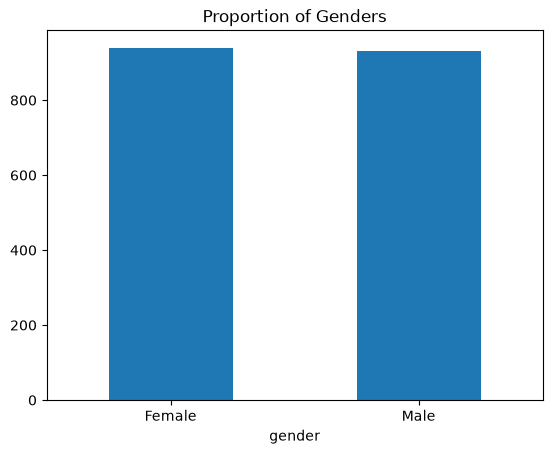

In [36]:
churned_counts_gender.plot(kind='bar',
                           title='Proportion of Genders',
                           x='gender',
                           y='Frequency',
                           rot=0);

There are 939 females (50.2%) and 930 males (49.8%) who churned, an almost even split.

In [37]:
# b) Who are the 10 churned customers with the longest tenure?
churned.sort_values(by='tenure', ascending=False)[
    ['customerID', 'tenure', 'Contract']].head(10)

,customerID,tenure,Contract
3439,0917-EZOLA,72,Two year
3111,8809-RIHDD,72,Two year
6424,6034-ZRYCV,72,Two year
4610,2889-FPWRM,72,One year
4513,8580-QVLOC,72,Two year
3890,3886-CERTZ,72,One year
4149,6559-ILWKJ,71,Two year
3040,7317-GGVPB,71,Two year
6398,3259-FDWOY,71,Two year
5702,5287-QWLKY,71,Month-to-month


In [38]:
# c) Rank the churned customers by TotalCharges and display the top 5
churned['ChargesRank'] = churned['TotalCharges'].rank(ascending=False)

churned.sort_values(by='ChargesRank')[
    ['customerID', 'TotalCharges', 'ChargesRank']].head(5)

,customerID,TotalCharges,ChargesRank
4610,2889-FPWRM,8684.80,1.0
1306,0201-OAMXR,8127.60,2.0
3890,3886-CERTZ,8109.80,3.0
6537,1444-VVSGW,7968.85,4.0
5581,5271-YNWVR,7856.00,5.0


`rank(ascending=False)` assigns position 1 to the largest value. Sorting by the new rank column then puts the highest-paying churned customers first, ties, if any, receive the average of the positions they span, which is why ranks can be non-integer.

In [39]:
# d) Create a slimmer view of churned by dropping the internet add-on columns
addon_columns = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

churned_slim = churned.drop(columns=addon_columns)
churned_lim.head()s

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,loyalty,CustomerValue,ChargesRank
2,3668-QPYBK,Male,0,0,0,2,1,No,DSL,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Bronze,low,1427.0
4,9237-HQITU,Female,0,0,0,2,1,No,Fiber optic,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Bronze,low,1373.0
5,9305-CDSKC,Female,0,0,0,8,1,Yes,Fiber optic,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,Bronze,low,881.0
8,7892-POOKP,Female,0,1,0,28,1,Yes,Fiber optic,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,Gold,high,338.0
13,0280-XJGEX,Male,0,0,0,49,1,Yes,Fiber optic,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,Gold,high,154.0


> ### 13. Senior Citizens that churned:
>    - a) Rank the churned seniors by `TotalCharges` and display the 5 highest-paying.
>    - b) Split the churned seniors into a `DSL` DataFrame and a `Fiber optic` DataFrame, then combine them back into one DataFrame with `pd.concat` and verify the row count.
>    - c) Compare the `PaymentMethod` counts of churned seniors against churned non-seniors using Series alignment.
>    - d) How many Seniors are in the `Gold` loyalty program or are a `low`-valued customer?
>    - e) Are there any Seniors that are in both the `Gold` loyalty program and considered a `low`-valued customer?

In [40]:
churned_seniors = churned[churned['SeniorCitizen'] == 1]
churned_seniors.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,loyalty,CustomerValue,ChargesRank
20,8779-QRDMV,Male,1,0,0,1,0,No phone service,DSL,No,...,Yes,Month-to-month,Yes,Electronic check,39.65,39.65,Yes,Bronze,low,1772.0
53,7495-OOKFY,Female,1,1,0,8,1,Yes,Fiber optic,No,...,No,Month-to-month,Yes,Credit card (automatic),80.65,633.30,Yes,Bronze,low,972.0
55,1658-BYGOY,Male,1,0,0,18,1,Yes,Fiber optic,No,...,Yes,Month-to-month,Yes,Electronic check,95.45,1752.55,Yes,Silver,medium,574.0
99,4598-XLKNJ,Female,1,1,0,25,1,No,Fiber optic,No,...,Yes,Month-to-month,Yes,Electronic check,98.50,2514.50,Yes,Gold,medium,427.0
113,4846-WHAFZ,Female,1,1,0,37,1,Yes,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,76.50,2868.15,Yes,Gold,medium,367.0


In [41]:
# a) Rank the churned seniors by TotalCharges and display the 5 highest-paying
churned_seniors['ChargesRank'] = churned_seniors['TotalCharges'].rank(ascending=False)

churned_seniors.sort_values(by='ChargesRank')[
    ['customerID', 'TotalCharges', 'ChargesRank']].head(5)

,customerID,TotalCharges,ChargesRank
3439,0917-EZOLA,7689.95,1.0
5702,5287-QWLKY,7548.10,2.0
6035,9835-ZIITK,7491.75,3.0
6605,7632-MNYOY,7432.05,4.0
2287,5440-FLBQG,7318.20,5.0


In [42]:
# b) Split by InternetService, then combine back with pd.concat
seniors_dsl = churned_seniors[churned_seniors['InternetService'] == 'DSL']
seniors_fiber = churned_seniors[churned_seniors['InternetService'] == 'Fiber optic']

seniors_combined = pd.concat([seniors_dsl, seniors_fiber])

print(f'DSL: {len(seniors_dsl)} rows')
print(f'Fiber optic: {len(seniors_fiber)} rows')
print(f'Combined: {len(seniors_combined)} rows')

DSL: 78 rows
Fiber optic: 393 rows
Combined: 471 rows


`pd.concat` stacks the two DataFrames on top of each other, and the combined row count equals the sum of the parts. Note the combined DataFrame has fewer rows than `churned_seniors` itself, seniors with no internet service (`InternetService` of `No`) were left out of both parts.

In [43]:
# c) Compare PaymentMethod counts: churned seniors vs. churned non-seniors
seniors_counts = churned_seniors['PaymentMethod'].value_counts()
non_seniors_counts = churned[churned['SeniorCitizen'] == 0]['PaymentMethod'].value_counts()

print(seniors_counts)
print()
print(non_seniors_counts)

PaymentMethod
Electronic check             317
Credit card (automatic)       62
Bank transfer (automatic)     53
Mailed check                  44
Name: count, dtype: int64

PaymentMethod
Electronic check             754
Mailed check                 264
Bank transfer (automatic)    205
Credit card (automatic)      170
Name: count, dtype: int64


In [44]:
# Subtraction pairs values by index label, not by position
difference = non_seniors_counts - seniors_counts

# reindex reorders the result to match the non-seniors ordering
difference.reindex(non_seniors_counts.index)

PaymentMethod
Electronic check             437
Mailed check                 220
Bank transfer (automatic)    152
Credit card (automatic)      108
Name: count, dtype: int64

When the two Series are subtracted, pandas pairs values by their **index labels** (the payment method names), not by their positions, this is alignment. The result initially comes back in label-sorted order, and `reindex` reorders it to match the ordering of the non-seniors counts. Every payment method appears in both groups here, so there are no NaN values; if a method existed in only one group, its difference would be NaN.

In [45]:
# d) How many Seniors are in the Gold loyalty program or are a
# low valued customer?
low_or_gold_seniors = churned_seniors[(churned_seniors['loyalty'] == 'Gold') |
                  (churned_seniors['CustomerValue'] == 'low')]
low_or_gold_seniors[['customerID', 'loyalty', 'CustomerValue']]

,customerID,loyalty,CustomerValue
20,8779-QRDMV,Bronze,low
53,7495-OOKFY,Bronze,low
99,4598-XLKNJ,Gold,medium
113,4846-WHAFZ,Gold,medium
126,4412-YLTKF,Gold,medium
...,...,...,...
6993,6583-QGCSI,Gold,high
7008,1980-KXVPM,Bronze,low
7010,0723-DRCLG,Bronze,low
7032,6894-LFHLY,Bronze,low


In [46]:
len(low_or_gold_seniors)

394

There are 394 Seniors who are in the Gold loyalty program OR are a low-valued customer.

In [47]:
# e) Are there any Seniors that are in both the Gold loyalty program
# and considered a low valued customer?
low_and_gold_seniors = churned_seniors[(churned_seniors['loyalty'] == 'Gold') &
                      (churned_seniors['CustomerValue'] == 'low')]
low_and_gold_seniors[['customerID', 'loyalty', 'CustomerValue']]

,customerID,loyalty,CustomerValue
358,9057-MSWCO,Gold,low


In [48]:
len(low_and_gold_seniors)

1

There is 1 Senior who is in the Gold loyalty program AND is a low-valued customer. Only 1 customer overlapping both groups also explains why the OR count in part d) is nearly the simple sum of the two groups.

---

## Congratulations!

You have cleaned and explored a realistic telecom churn dataset end to end: converting problem columns to usable data types, replacing values with `replace` and `map`, building categorical columns with list comprehensions and `apply`, sorting and ranking customers, filtering with simple and compound boolean masks, combining DataFrames with `pd.concat`, reordering labels with `reindex`, and comparing groups through index alignment. Later in the course, you will revisit this kind of analysis with joins, aggregations, and data reshaping, which make several of these questions answerable in even fewer steps.